In [1]:
import py4DSTEM
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from colorsys import hsv_to_rgb
import numpy as np
import matplotlib.pyplot as plt
import string

C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH

# Load Data

In [2]:
# Columns represent Qx, Qy, I, Rx, Ry, Qr, Qphi
PeaksArray = np.load('PeaksArray_SmallRange.npy')
Qx = PeaksArray[:, 0]
Qy = PeaksArray[:, 1]
Rx = PeaksArray[:, 3]
Ry = PeaksArray[:, 4]

In [3]:
# Set same text size
plt.rcParams.update({'font.size': 14})

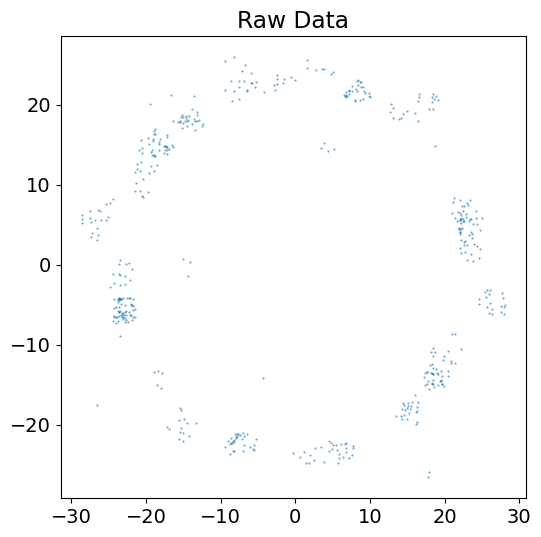

In [4]:
# Plot the data
plt.figure(figsize=[6,6])
plt.title('Raw Data')
plt.scatter(Qx, Qy, s=0.25, alpha=0.7)
plt.show()

# DBSCAN

## Level 1 clustering

In [5]:
# DBScan Parameters
s = 0.4 
eps = 2
db = DBSCAN(eps=eps, min_samples=4).fit(PeaksArray[:,[0,1,3,4]]*np.array([1, 1, s, s])) 

In [6]:
# Colour Scheme
colours = []
r = db.labels_.max()+1
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 

### Plots

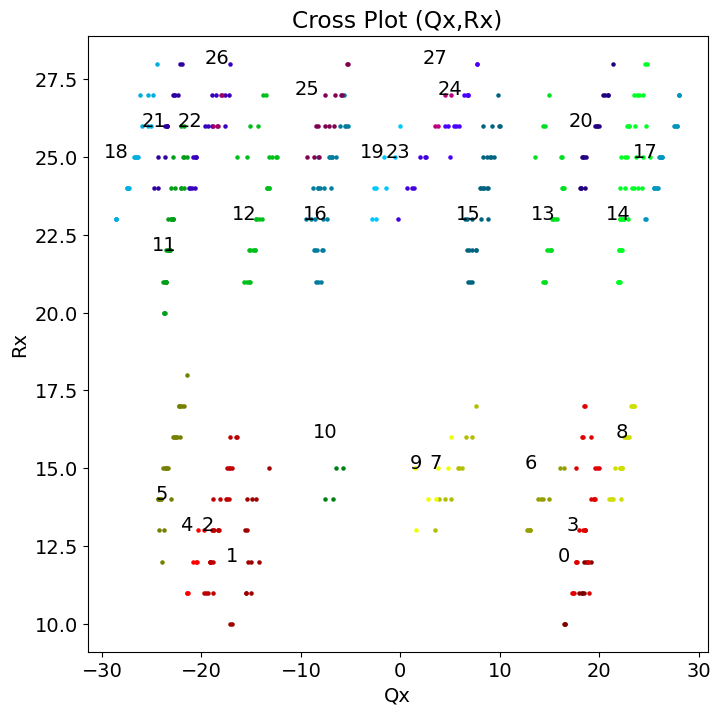

In [7]:
# Cross Plot (Qx,Rx)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qx,Rx)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 3], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 3]+2, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qx')
plt.ylabel('Rx')
plt.show()

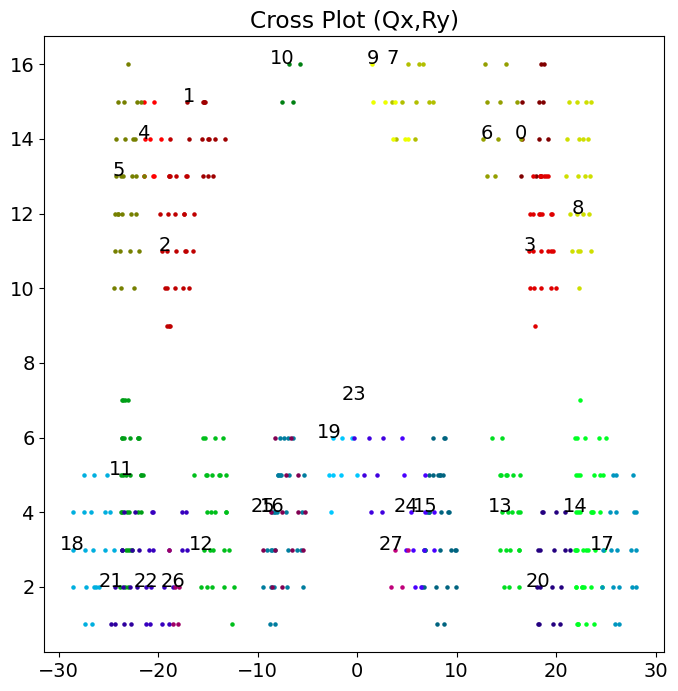

In [8]:
# Cross Plot (Qx,Ry)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qx,Ry)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 4], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 4]+1, 
            int(i),
            horizontalalignment='center'
        )

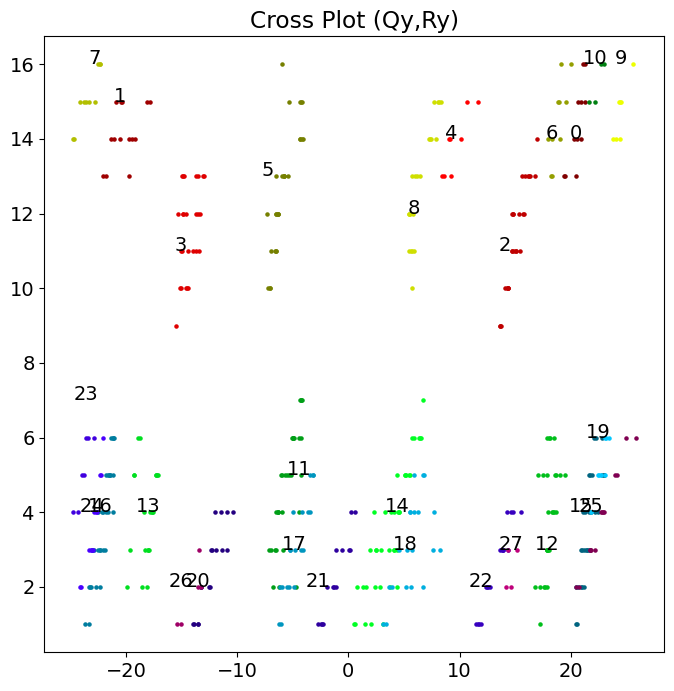

In [9]:
# Cross Plot (Qy,Ry)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qy,Ry)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 4], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 4]+1, 
            int(i),
            horizontalalignment='center'
        )

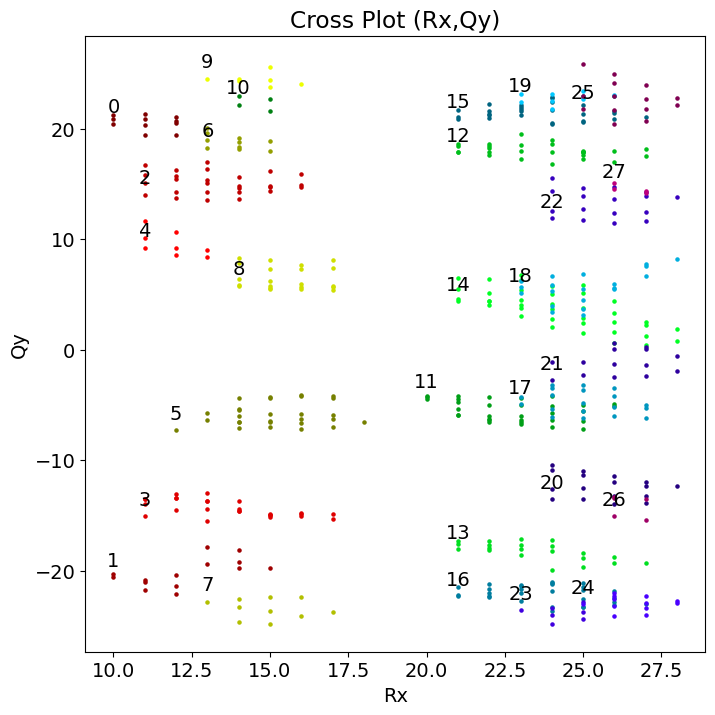

In [10]:
# Cross Plot (Rx,Qy)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Rx,Qy)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 3], Cluster[:, 1], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 3], 
            Cluster[n, 1]+1, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Rx')
plt.ylabel('Qy')
plt.show()

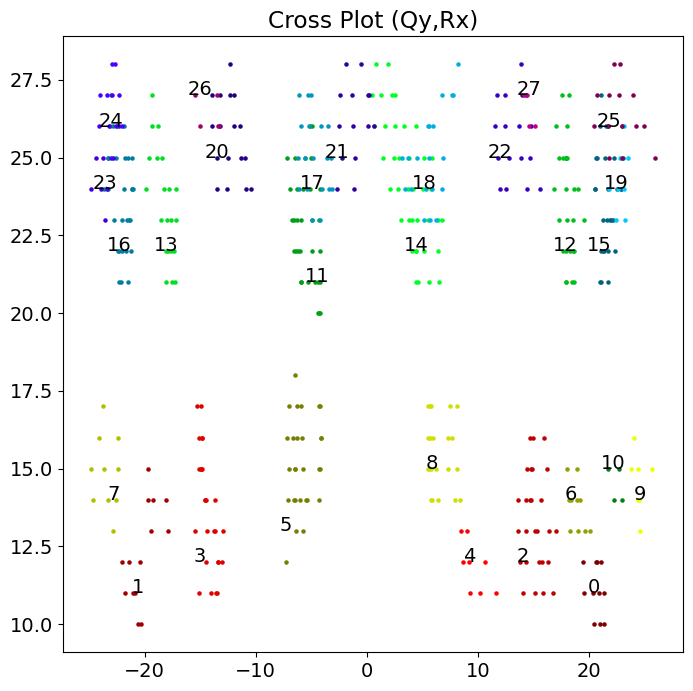

In [11]:
# Cross Plot (Qy,Rx)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qy,Rx)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 3], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 3]+1, 
            int(i),
            horizontalalignment='center'
        )

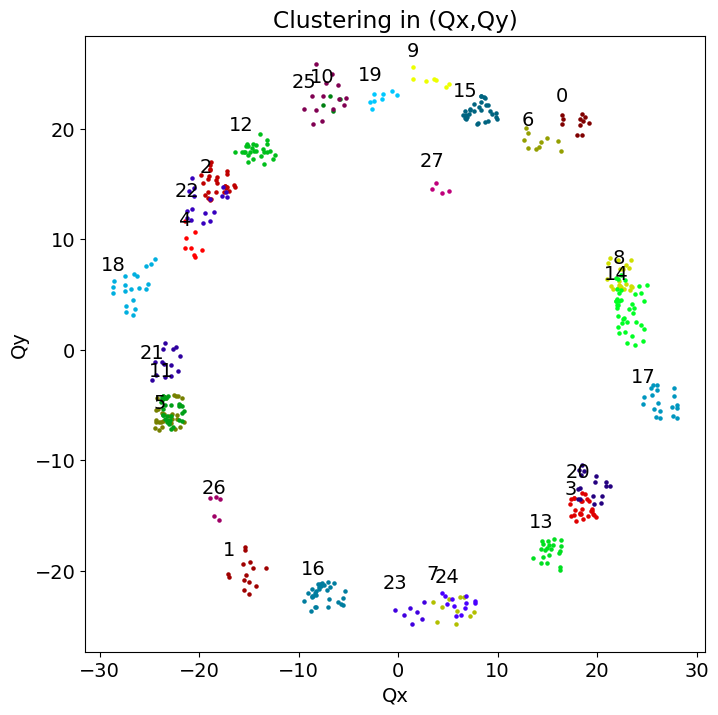

In [12]:
# Apply DBScan
plt.figure(figsize=[8,8])
plt.title('Clustering in (Qx,Qy)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 1], color = colours[i], label = i, s=5, alpha=1)  
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 1]+2, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qx')
plt.ylabel('Qy')
plt.show()

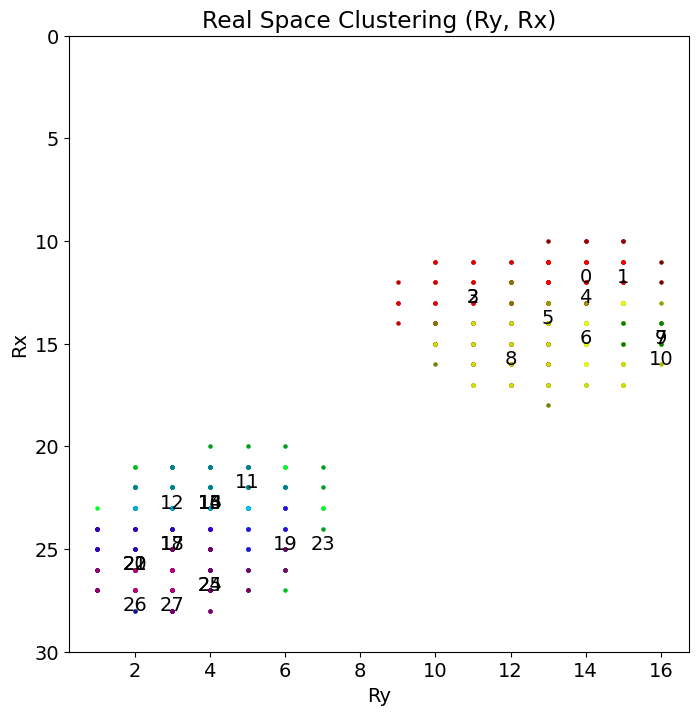

In [13]:
# Real space
plt.figure(figsize=[8,8])
plt.title('Real Space Clustering (Ry, Rx)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 4], Cluster[:, 3], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],1000): # number of iterations 
        plt.text(
            Cluster[n, 4]+1, 
            Cluster[n, 3]+2, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Ry')
plt.ylabel('Rx')
plt.ylim(30,0)
plt.show()

## Centre of Mass

In [14]:
# find COM for each cluster

def COM_X(m,x):
    '''
    Calculates COM for x-coordinate.

    Data types:
    m: int or numpy array
    x: numpy array
    '''
    return (np.sum(m * x)) / np.sum(m)

def COM_Y(m,y):
    '''
    Calculates COM for y-coordinate.

    Data types:
    m: int or numpy array
    y: numpy array
    '''
    return (np.sum(m * y)) / np.sum(m)

def Cluster_COM(Data, Range, label, Weight=True):
    '''
    Calculates COM for every cluster in a clustering graph.
    
    Data types:
    Data: numpy array
    Range: numpy array
    label: numpy array
    Weight: bool
        if True, applies pixel weighting to the centre of masses

    '''
    COM_Values = []

    # loop over all clusters
    for p in Range:
        Cluster = Data[np.where(label == p)]

        if Weight:
            # COM weighting
            COM_Values.append((
                COM_X(Cluster[:,2], Cluster[:,3]),
                COM_Y(Cluster[:,2], Cluster[:,4])
            ))

        else:
            #COM no weighting
            COM_Values.append((
                COM_X(1, Cluster[:,3]),
                COM_Y(1, Cluster[:,4])
            ))
            
    return COM_Values

In [15]:
Data = PeaksArray
Range = np.arange(0, max(db.labels_)+1,1)

In [16]:
COM_Values = Cluster_COM(Data, Range, db.labels_, Weight = True)

In [17]:
COM_Values = np.array(COM_Values)

## Level 2 Clustering (Clustering on COM)

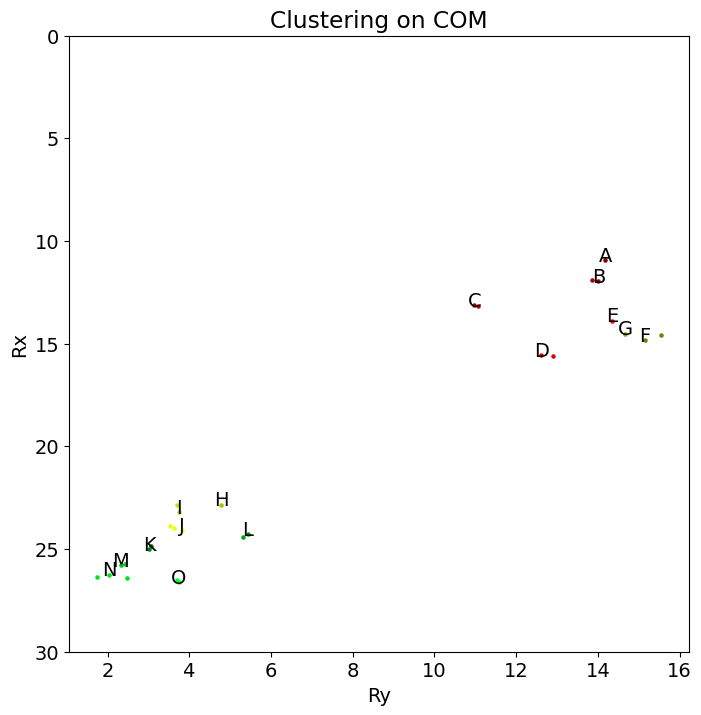

In [18]:
# Second level clustering on COM
db2 = DBSCAN(eps=0.5, min_samples=1).fit(COM_Values)

# Plot
plt.figure(figsize=[8,8])
plt.title('Clustering on COM')

Text = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

for i in range(r):   
    Cluster = COM_Values[np.where(db2.labels_ == i)]
    scatter = plt.scatter(Cluster[:,1], Cluster[:,0], color = colours[i], label = i, s=5, alpha=1)

    for n in range(0,Cluster.shape[0],1000): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 0]+.05, 
            str(Text[i]),
            horizontalalignment='center'
        )
plt.ylim(30,0)
plt.xlabel('Ry')
plt.ylabel('Rx')
plt.show()

## Virtual Images of Individual Crystals

In [19]:
Cluster = COM_Values[np.where(db2.labels_ == 0)]

In [20]:
Rxc = Cluster[:, 0]
Ryc = Cluster[:, 1]

In [21]:
# Finding max dimensions of Rx, Ry
Rxmax, Rymax = COM_Values[:,0].max().astype('int')+1, COM_Values[:,1].max().astype('int')+1

In [22]:
# Create image 
image = np.zeros(shape=(Rxmax,Rymax))
image[Rxc.astype('int'), Ryc.astype('int')]  = Cluster[:,1]

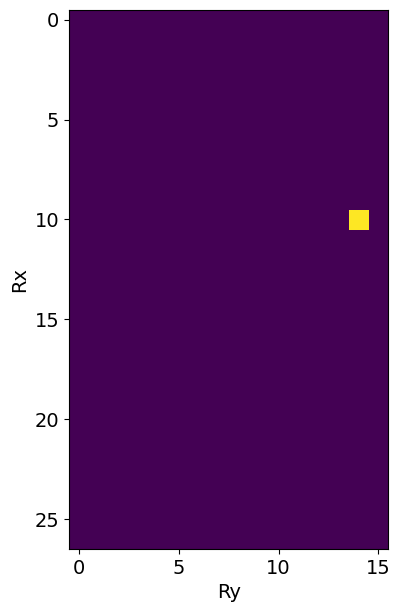

In [23]:
# Plot
plt.figure(figsize=[7,7])
plt.xlabel('Ry')
plt.ylabel('Rx')
plt.imshow(image)
plt.show()

In [24]:
def VirtualImage(Data, Label, Index, x, y, Rx, Ry):
    '''
    Function which produces the Digital Dark Field Image of a selected cluster

    Data types:
    Data: numpy array
    Label: numpy array
        this corresponds to the clustering type, so for DBSCAN use db.labels_
        
    Index: Int
        select the index of the cluster
    x: Int 
    y: Int 
    Rx: numpy array
    Ry: numpy array
    returns: NoneType
        virtual image of cluster
    '''
    Cluster = Data[np.where(Label == Index)]

    Rxc = Cluster[:, x]
    Ryc = Cluster[:, y]

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = Rx.max().astype('int')+1, Ry.max().astype('int')+1
    
    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')]  = Cluster[:,1]

    # Plot
    plt.figure(figsize=[7,7])
    plt.xlabel('Ry')
    plt.ylabel('Rx')
    plt.imshow(image)
    plt.show()

# may want to add subplots to this to be able to save image

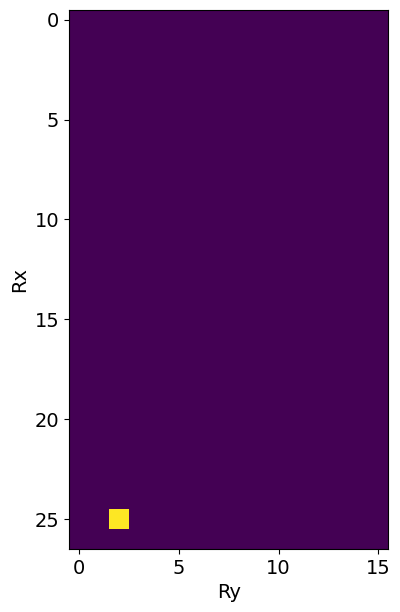

In [25]:
VirtualImage(COM_Values, db2.labels_, 12, 0, 1, COM_Values[:,0], COM_Values[:,1])

## Transfer level 1 and level 2 cluster labels into the data array 

## Try

In [26]:
# Identify the unique labels in level 2
L2numlabs = np.unique(db2.labels_)

# Insert alphabetical letters
L2letterlabs = string.ascii_uppercase[:L2numlabs.shape[0]]

# Create dict
L2labs = dict(list(zip(L2letterlabs,L2numlabs)))
L2labs2 = dict(list(zip(L2numlabs, L2letterlabs)))

In [27]:
# Add level 1 labels to data array
Dataset = np.column_stack((PeaksArray, db.labels_))

In [29]:
indexing = db2.labels_[db.labels_] # indexing to ensure correct length of lvl2 labels

In [30]:
# Source - https://stackoverflow.com/a/57058920
# Posted by yatu
# Retrieved 2026-03-15, License - CC BY-SA 4.0
l1 = np.vectorize(L2labs2.get)(indexing.astype(int))

In [34]:
FullDataset = np.column_stack((Dataset, l1))

In [120]:
print(FullDataset)

[['16.436014564864934' '20.45388999042433' '35.35892918524896' ...
  '-38.78411382964208' '0.0' 'A']
 ['16.552233963078592' '20.93720501121021' '147.81662885891163' ...
  '-38.32868345393691' '0.0' 'A']
 ['-16.9481985628191' '-20.57194090559291' '79.53160130851654' ...
  '140.5165882328975' '1.0' 'B']
 ...
 ['7.72036717926521' '-22.703672742825034' '49.494181470254425' ...
  '-161.21943674107945' '24.0' 'O']
 ['-5.261900586430684' '22.791778521407636' '34.30814255563038' ...
  '13.00000932390313' '25.0' 'O']
 ['14.217430471996451' '-18.947646856382505' '28.530083861893416' ...
  '-143.1171471091629' '-1.0' 'N']]


In [121]:
# New Data Array Columns
Qx = FullDataset[:,0]
Qy = FullDataset[:,1]
I = FullDataset[:,2]
Rx = FullDataset[:,3]
Ry = FullDataset[:,4] 
Qr = FullDataset[:,5]
Qphi = FullDataset[:,6]
Clusters1 = FullDataset[:,7]
Clusters2 = FullDataset[:,8] 

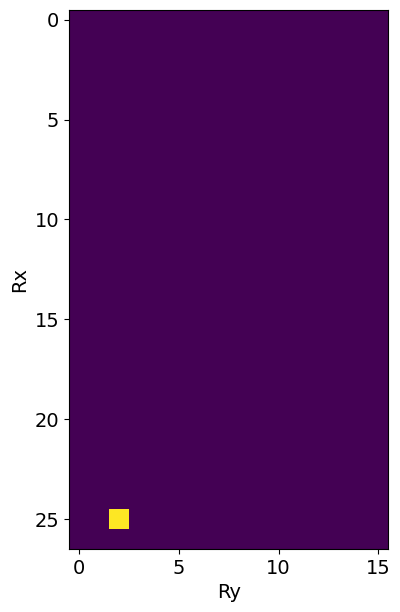

In [122]:
# Try Virtual Images on new dataset for individual crystals using dict
VirtualImage(COM_Values, db2.labels_, L2labs['M'], 0, 1, COM_Values[:,0], COM_Values[:,1])

## Cluster on Qx, Qy for individual Crystals

In [196]:
# Example Select Crystal A (CA)
CA = FullDataset[:, 8] == 'A'

# All diffraction vectors associated with Crystal A
CA_FullDataset = FullDataset[CrystalA]

# Change values into floats
CA_Data = CA_FullDataset[:,0:8].astype(float)

# Extract Qx, Qy from crystal A
Aqx = CA_Data[:,0]
Aqy = CA_Data[:,1]

In [204]:
# DBScan Parameters
#s = 0.4 
#eps = 1
db3 = DBSCAN(eps=0.1, min_samples=1).fit(CA_Data[:,[0, 1, 3, 4]]) 

In [205]:
# Colour Scheme
colours = []
r = db3.labels_.max()+1
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 

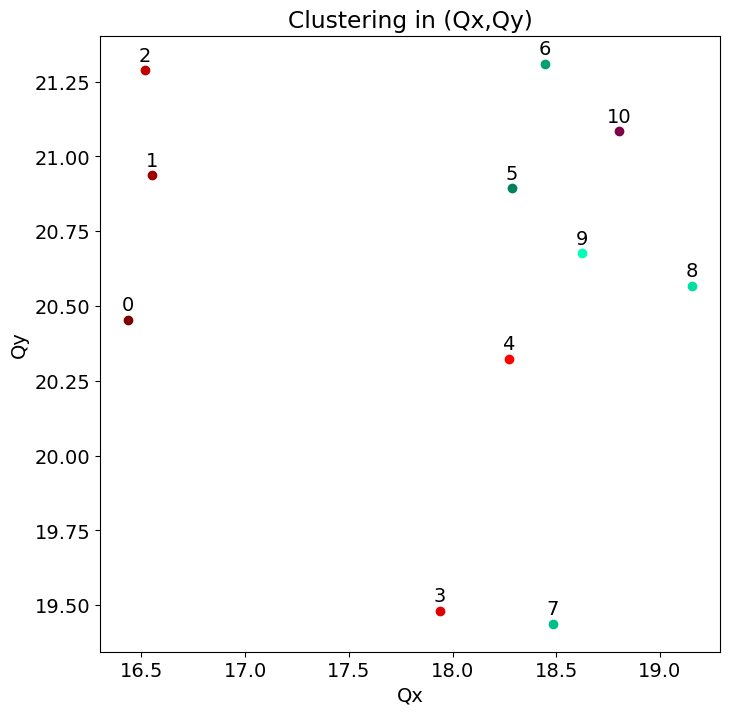

In [211]:
# Apply DBScan
plt.figure(figsize=[8,8])
plt.title('Clustering in (Qx,Qy)')

for i in range(r):   
    Cluster = CA_Data[np.where(db3.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 1], color = colours[i], label = i)  
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 1]+0.03, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qx')
plt.ylabel('Qy')
plt.show()